#  MuJoCo Bootcamp : Control a simple pendulum

---- 

- conda env : [ai_robotics](../../../README.md#setup-a-conda-environment)

---

### Reference : 
- https://pab47.github.io/mujoco.html
- https://youtu.be/JNgO_OPVb5k

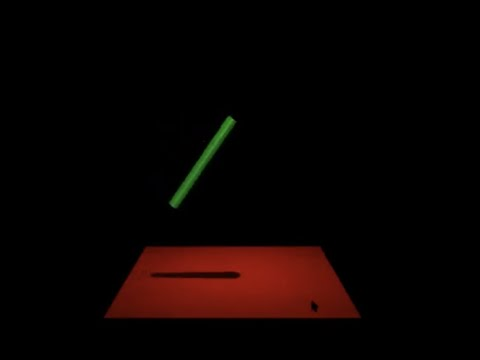

In [1]:
from IPython.display import YouTubeVideo

YouTubeVideo('JNgO_OPVb5k')

## Run python code

In [ ]:
!python control_pendulum.py

## Jupyter code

### Load XML file and build model and data

In [1]:
import mujoco as mj
import numpy as np
import mediapy as media

# Create an XML file string for a simple ball on a plane
xml_path = "./pendulum.xml" 

# MuJoCo data structures
model = mj.MjModel.from_xml_path(xml_path)
data = mj.MjData(model)

### Setup the controller

In [2]:
def controller(model, data):
    """
    This function implements a PD controller

    Since there are no gravity compensation,
    it will not be very accurate at tracking
    the set point. It will be accurate if
    gravity is turned off.
    """
    if actuator_type == "torque":
        model.actuator_gainprm[0, 0] = 1
        data.ctrl[0] = -10 * \
            (data.sensordata[0] - 0.0) - \
            1 * (data.sensordata[1] - 0.0)
    elif actuator_type == "servo":
        kp = 10.0
        model.actuator_gainprm[1, 0] = kp
        model.actuator_biasprm[1, 1] = -kp
        data.ctrl[1] = -0.5

        kv = 1.0
        model.actuator_gainprm[2, 0] = kv
        model.actuator_biasprm[2, 2] = -kv
        data.ctrl[2] = 0.0

#set the controller
actuator_type = "torque"
mj.set_mjcb_control(controller)

### Setup the configuration of render

In [3]:
# Offscreen rendering setup
width, height = 200, 200
renderer = mj.Renderer(model, width, height)

# Set camera configuration
cam = mj.MjvCamera()
mj.mjv_defaultCamera(cam)
cam.azimuth = 90.0
cam.distance = 5.0
cam.elevation = -5
cam.lookat = np.array([0.012768, -0.000000, 1.254336])

### Initialization 

In [4]:
# Reset the data to initial state
mj.mj_resetData(model, data)

#set initial conditions
data.qpos[0] = np.pi/2



### Simulation

In [5]:
# Store frames for visualization
frames = []
framerate = 60
simend = 5

while data.time < simend:
    # Perform a single simulation step
    simstart = data.time

    while (data.time - simstart < 1.0/60.0):
        mj.mj_step(model, data)
    
    # Render the scene from the specified camera
    renderer.update_scene(data, camera=cam)
    
    # Get the rendered RGB image and store it
    rgb_image = renderer.render()
    frames.append(rgb_image)

media.show_video(frames, fps=framerate)




This browser does not support the video tag.
